<a href="https://www.kaggle.com/code/matheusgabrielalves/ia-svm-aptid-o-f-sica-6b-noite?scriptVersionId=350444818" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Análise de Classificação com SVM
## Fitness Classification Dataset (Synthetic)

---

**Disciplina:** Inteligência Artificial  
**Curso:** Engenharia de Software  
**Turma:** 6B — Noite  
**Orientador:** Prof. Fabiano Bezerra Menegidio  
**Data:** 16/09/2026

---

### Integrantes

**Matheus Gabriel Alves da Silva** — RGM 11241100109  
**José Murilo de Sá Bezerra** — RGM 11241103548

## 1. Definição do Problema

**Tema:** identificar se uma pessoa pode ser considerada fisicamente apta (*fit*).

**Tipo:** classificação binária | **Algoritmo:** SVM

**Variável alvo:** `is_fit`
- `0` — Não apto (60,05%)
- `1` — Apto (39,95%)

**Preditores:** idade, altura, peso, frequência cardíaca, pressão arterial, gênero, horas de sono, qualidade nutricional, índice de atividade e tabagismo.

**Baseline:** 60,05%. É a acurácia de chutar sempre a classe majoritária — o modelo precisa superar esse valor para ter utilidade.

## 2. Importação do Dataset

In [18]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Localiza o arquivo do dataset anexado
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/muhammedderric/fitness-classification-dataset-synthetic/README.md
/kaggle/input/datasets/muhammedderric/fitness-classification-dataset-synthetic/fitness_dataset.csv
/kaggle/input/datasets/muhammedderric/fitness-classification-dataset-synthetic/dataset-metadata.json


In [3]:
df=pd.read_csv("/kaggle/input/datasets/muhammedderric/fitness-classification-dataset-synthetic/fitness_dataset.csv")

df.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


## 3. Avaliação do Banco de Dados

Inspeção da estrutura, tipos de dados, estatísticas descritivas e distribuição das variáveis categóricas.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        1840 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   object 
 9   gender             2000 non-null   object 
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 172.0+ KB


In [5]:
df.isnull().sum()

age                    0
height_cm              0
weight_kg              0
heart_rate             0
blood_pressure         0
sleep_hours          160
nutrition_quality      0
activity_index         0
smokes                 0
gender                 0
is_fit                 0
dtype: int64

In [6]:
df.describe()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,is_fit
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,1840.000000,2000.000000,2000.000000,2000.000000
mean,49.114000,174.53300,83.540500,70.288600,119.908850,7.513315,5.035140,2.999040,0.399500
std,17.926564,14.37175,25.852534,11.846339,14.578032,1.502031,2.864156,1.136383,0.489918
min,18.000000,150.00000,30.000000,45.000000,90.000000,4.000000,0.000000,1.000000,0.000000
25%,34.000000,162.00000,64.000000,62.100000,109.700000,6.500000,2.547500,2.037500,0.000000
50%,49.000000,174.00000,83.000000,70.250000,120.000000,7.500000,5.065000,2.980000,0.000000
75%,65.000000,187.00000,102.000000,78.425000,129.800000,8.600000,7.470000,3.950000,1.000000
max,79.000000,199.00000,250.000000,118.600000,171.200000,12.000000,10.000000,4.990000,1.000000


In [7]:
print("--- SMOKES ---")
print(df['smokes'].value_counts())

print("\n--- GENDER ---")
print(df['gender'].value_counts())

print("\n--- IS_FIT (alvo) ---")
print(df['is_fit'].value_counts(normalize=True).round(4))

print("\nDuplicadas:", df.duplicated().sum())

print("\nPeso < 45kg:", (df['weight_kg'] < 45).sum())
print("Peso > 180kg:", (df['weight_kg'] > 180).sum())

--- SMOKES ---
smokes
yes    711
0      581
no     518
1      190
Name: count, dtype: int64

--- GENDER ---
gender
F    1030
M     970
Name: count, dtype: int64

--- IS_FIT (alvo) ---
is_fit
0    0.6005
1    0.3995
Name: proportion, dtype: float64

Duplicadas: 0

Peso < 45kg: 19
Peso > 180kg: 21


**Achados da avaliação:**

- **Dimensões:** 2.000 × 11
- **Ausentes:** 160 em `sleep_hours` (8%)
- **Duplicadas:** nenhuma
- **Categóricas:** `smokes` e `gender`
- **Problema em `smokes`:** quatro representações (`yes`, `no`, `1`, `0`) para dois valores
- **Outliers em `weight_kg`:** 40 registros (2% da base)
- **Escalas:** muito diferentes entre colunas

### 3.1 Análise Visual Exploratória

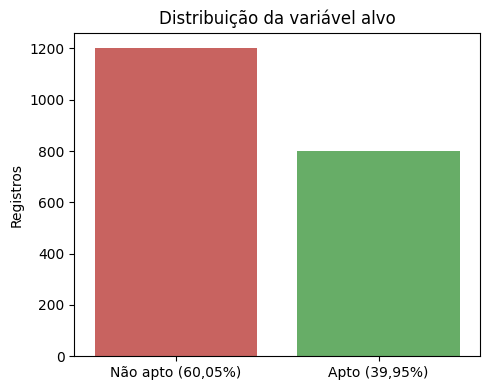

In [8]:
plt.figure(figsize=(5, 4))

sns.countplot(
    data=df,
    x='is_fit',
    hue='is_fit',
    palette=['#d9534f', '#5cb85c'],
    legend=False
)

plt.title('Distribuição da variável alvo')
plt.xticks([0, 1], ['Não apto (60,05%)', 'Apto (39,95%)'])
plt.xlabel('')
plt.ylabel('Registros')
plt.tight_layout()
plt.show()

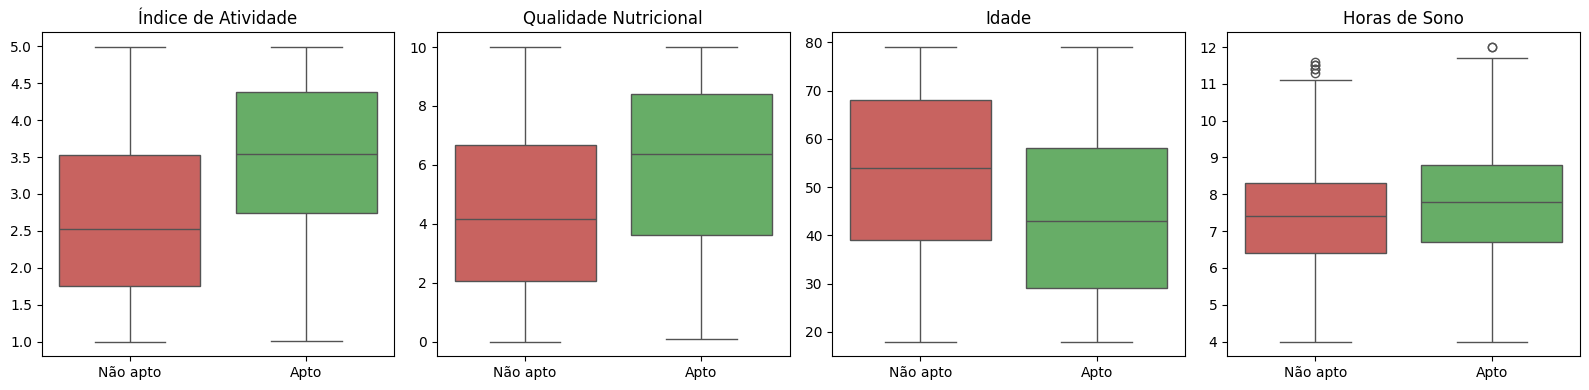

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

cols = ['activity_index', 'nutrition_quality', 'age', 'sleep_hours']
nomes = ['Índice de Atividade', 'Qualidade Nutricional', 'Idade', 'Horas de Sono']

for ax, col, nome in zip(axes, cols, nomes):
    sns.boxplot(
        data=df,
        x='is_fit',
        y=col,
        hue='is_fit',
        ax=ax,
        palette=['#d9534f', '#5cb85c'],
        legend=False
    )
    ax.set_title(nome)
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Não apto', 'Apto'])
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

**Leitura dos gráficos:**

- Desbalanceamento leve (60/40), sem necessidade de reamostragem.
- Atividade física e nutrição separam melhor as classes que as variáveis biométricas.
- Tabagismo é o contraste mais forte: 53% dos não fumantes são aptos, contra 24% dos fumantes.
- As distribuições se sobrepõem em todas as variáveis — nenhum atributo isolado decide a classificação, o que justifica o uso do SVM.

## 4. Tratativa de Dados Ausentes

A coluna `sleep_hours` apresenta 160 valores ausentes (8% da base). Antes de 
definir o tratamento, verificamos se a ausência está associada à variável alvo.

In [11]:
print("% de ausentes por coluna:")
print((df.isnull().mean() * 100).round(2))

print("\nTeste de viés — média de is_fit conforme sleep_hours está ausente:")
print(df.assign(faltou=df['sleep_hours'].isna()).groupby('faltou')['is_fit'].mean().round(4))

% de ausentes por coluna:
age                  0.0
height_cm            0.0
weight_kg            0.0
heart_rate           0.0
blood_pressure       0.0
sleep_hours          8.0
nutrition_quality    0.0
activity_index       0.0
smokes               0.0
gender               0.0
is_fit               0.0
dtype: float64

Teste de viés — média de is_fit conforme sleep_hours está ausente:
faltou
False    0.3984
True     0.4125
Name: is_fit, dtype: float64


**Resultado:** a proporção de aptos é praticamente idêntica entre registros com e 
sem `sleep_hours` (0,3984 contra 0,4125). A ausência é aleatória (MCAR), não 
associada ao alvo.

**Decisão:** imputação pela **mediana**. Descartar as linhas eliminaria 8% da 
amostra sem necessidade; a mediana foi escolhida em vez da média por ser 
resistente a valores extremos.

In [12]:
mediana = df['sleep_hours'].median()
df['sleep_hours'] = df['sleep_hours'].fillna(mediana)

print(f"160 valores imputados com a mediana: {mediana}")
print("Nulos restantes em sleep_hours:", df['sleep_hours'].isnull().sum())

160 valores imputados com a mediana: 7.5
Nulos restantes em sleep_hours: 0


## 5. Tratativa de Encoding

As colunas `smokes` e `gender` são categóricas (`object`) e precisam ser convertidas para numérico, pois o SVM opera apenas sobre dados numéricos.

**Problema identificado:** a coluna `smokes` possui quatro representações para dois valores lógicos:

- **Fumante:** `yes` (711 registros) e `1` (190 registros) — total 901
- **Não fumante:** `no` (518 registros) e `0` (581 registros) — total 1.099

Aplicar `get_dummies` diretamente criaria quatro colunas em vez de uma, distorcendo a variável. Por isso, normalizamos o texto antes do mapeamento.

In [13]:
# Normalização do texto antes do mapeamento
df['smokes'] = df['smokes'].astype(str).str.strip().str.lower()
df['gender'] = df['gender'].astype(str).str.strip().str.upper()

# Unificação das representações em binário
df['smokes'] = df['smokes'].map({'yes': 1, 'no': 0, '1': 1, '0': 0})
df['gender'] = df['gender'].map({'M': 0, 'F': 1})

print("--- SMOKES após encoding ---")
print(df['smokes'].value_counts(dropna=False))
print("\n--- GENDER após encoding ---")
print(df['gender'].value_counts(dropna=False))

--- SMOKES após encoding ---
smokes
0    1099
1     901
Name: count, dtype: int64

--- GENDER após encoding ---
gender
1    1030
0     970
Name: count, dtype: int64


## 6. Validação Final

Verificação de que a base está pronta para a modelagem: sem valores ausentes e 
sem variáveis categóricas.

In [14]:
print("Total de nulos:", df.isnull().sum().sum())
print("\nTipos de dados:")
print(df.dtypes)
print("\nDimensões finais:", df.shape)

Total de nulos: 0

Tipos de dados:
age                    int64
height_cm              int64
weight_kg              int64
heart_rate           float64
blood_pressure       float64
sleep_hours          float64
nutrition_quality    float64
activity_index       float64
smokes                 int64
gender                 int64
is_fit                 int64
dtype: object

Dimensões finais: (2000, 11)


In [17]:
bom = df[(df['activity_index'] > 4) & (df['nutrition_quality'] > 7) & (df['smokes'] == 0)]
ruim = df[(df['activity_index'] < 2) & (df['nutrition_quality'] < 3) & (df['smokes'] == 1)]

print(f"Perfil favorável  (n={len(bom)}): {bom['is_fit'].mean()*100:.1f}% aptos")
print(f"Perfil desfavorável (n={len(ruim)}): {ruim['is_fit'].mean()*100:.1f}% aptos")

Perfil favorável  (n=82): 95.1% aptos
Perfil desfavorável (n=72): 6.9% aptos


**Consistência do rótulo:** verificamos que `is_fit` segue lógica coerente com as variáveis — quem tem alta atividade física, boa nutrição e não fuma é classificado como apto em 95,1% dos casos, contra 6,9% no perfil oposto. Isso confirma que o rótulo não é aleatório e que existe padrão aprendível pelo modelo.

### 6.1 Matriz de Correlação

Com todas as variáveis convertidas para numérico, é possível avaliar a relação linear entre os preditores e a variável alvo.


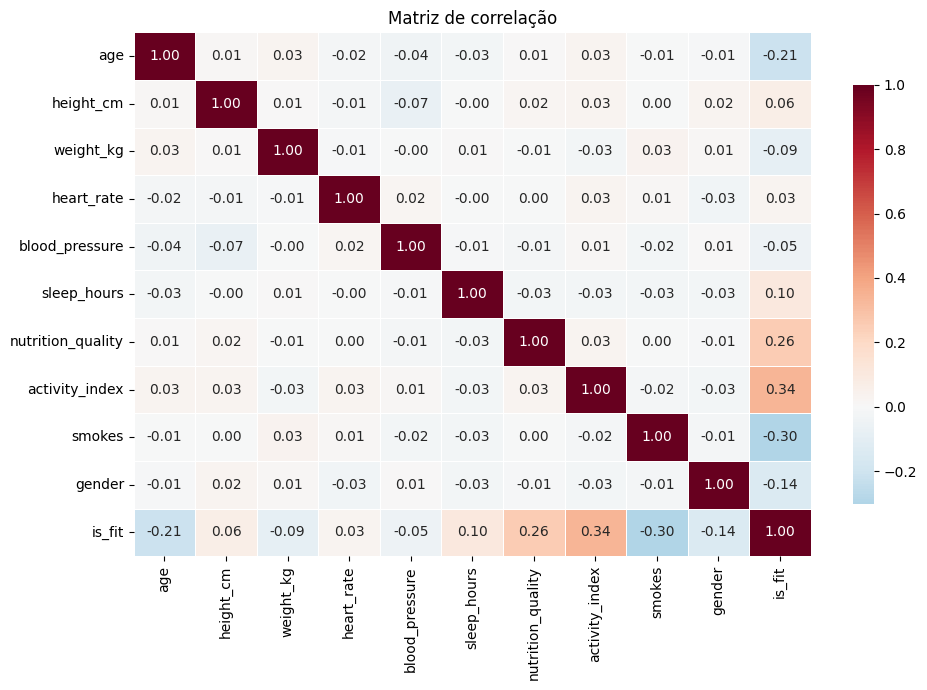

In [15]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de correlação')
plt.tight_layout()
plt.show()

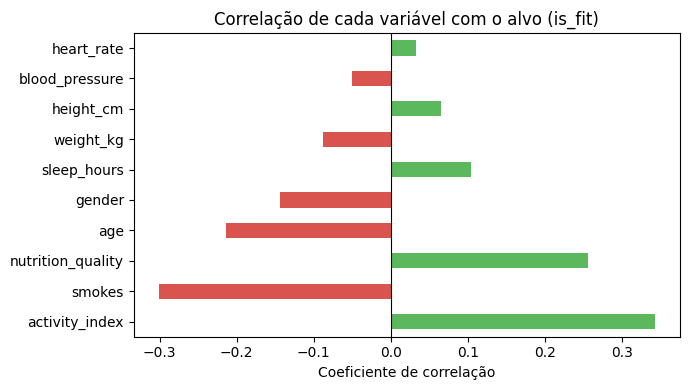

activity_index       0.343
smokes              -0.302
nutrition_quality    0.255
age                 -0.214
gender              -0.144
sleep_hours          0.105
weight_kg           -0.088
height_cm            0.065
blood_pressure      -0.051
heart_rate           0.033
Name: is_fit, dtype: float64


In [16]:
corr = df.corr()['is_fit'].drop('is_fit').sort_values(key=abs, ascending=False)

plt.figure(figsize=(7, 4))

cores = ['#5cb85c' if v > 0 else '#d9534f' for v in corr]
corr.plot(kind='barh', color=cores)

plt.title('Correlação de cada variável com o alvo (is_fit)')
plt.xlabel('Coeficiente de correlação')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(corr.round(3))

**Leitura da correlação:**

- `activity_index` (+0,34) — maior preditor; atividade física eleva a aptidão
- `smokes` (−0,30) — tabagismo reduz a aptidão
- `nutrition_quality` (+0,26) — alimentação de qualidade eleva a aptidão
- `age` (−0,21) — aptidão decresce com a idade
- `heart_rate` (+0,03) e `blood_pressure` (−0,05) — sem poder discriminante

As variáveis comportamentais discriminam melhor a aptidão física do que os indicadores biométricos. Frequência cardíaca e pressão arterial, apesar de parecerem os indicadores mais relevantes do ponto de vista clínico, não separam as classes neste conjunto de dados.

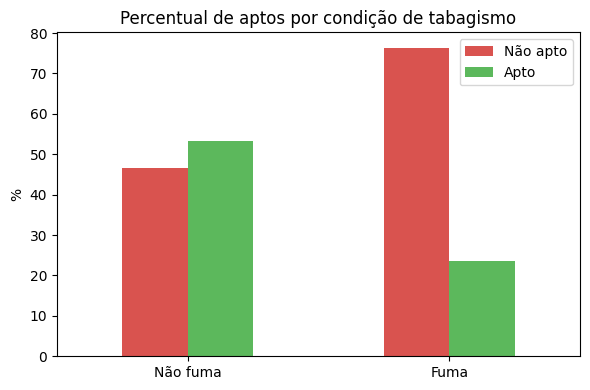

In [19]:
tab = pd.crosstab(df['smokes'], df['is_fit'], normalize='index') * 100

tab.plot(kind='bar', figsize=(6, 4), color=['#d9534f', '#5cb85c'])

plt.title('Percentual de aptos por condição de tabagismo')
plt.xticks([0, 1], ['Não fuma', 'Fuma'], rotation=0)
plt.xlabel('')
plt.ylabel('%')
plt.legend(['Não apto', 'Apto'])
plt.tight_layout()
plt.show()

## 7. Limitações Identificadas

- **Base sintética:** o rótulo `is_fit` foi definido pelo autor do dataset e não é diagnóstico clínico. Os resultados não valem como avaliação médica.

- **Outliers em `weight_kg`:** 40 registros com peso atípico (2% da base). Mantidos por representarem fração pequena da amostra.

- **Escalas heterogêneas:** as variáveis têm amplitudes muito diferentes. O `StandardScaler` será obrigatório antes do SVM, senão as variáveis de maior magnitude dominam o cálculo.

## 8. Conclusão da Etapa

A base está preparada para a modelagem:

- **Valores ausentes:** 0
- **Variáveis categóricas:** 0 (todas convertidas)
- **Registros preservados:** 2.000 (100%)
- **Colunas:** 11

**Próximas etapas:**

- **17/09/2026** — divisão em treino e teste, padronização, `GridSearchCV` e treinamento do modelo.
- **23/09/2026** — avaliação final e redação dos resultados.